In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
%matplotlib inline

In [3]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!wget -N $data

--2026-10-04 20:40:46--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.03s   

Last-modified header missing -- time-stamps turned off.
2026-10-04 20:40:46 (17.6 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



In [4]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [5]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_') #ensure all columns are lower case and blank spaces replaced with _

In [7]:
df.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [8]:
#create table subset only with required columns
df = df[['model_year', 'engine_displacement','horsepower','vehicle_weight','fuel_efficiency_mpg']] 
df.head()

,model_year,engine_displacement,horsepower,vehicle_weight,fuel_efficiency_mpg
0,2006,2180,243.0,3870,31.9
1,2008,2390,272.0,4210,31.3
2,1996,2320,267.0,4240,27.5
3,1989,2130,258.0,4490,28.5
4,1994,2580,304.0,4510,31.0


In [9]:
#This code is not applicable to the homework since all columns are non-string
#Stores in a variable the columns with datatypes of strings.
strings = list(df.dtypes[df.dtypes == 'str'].index)
#Replace blank spaces with "_" for each string column
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [10]:
df.dtypes

model_year               int64
engine_displacement      int64
horsepower             float64
vehicle_weight           int64
fuel_efficiency_mpg    float64
dtype: object

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

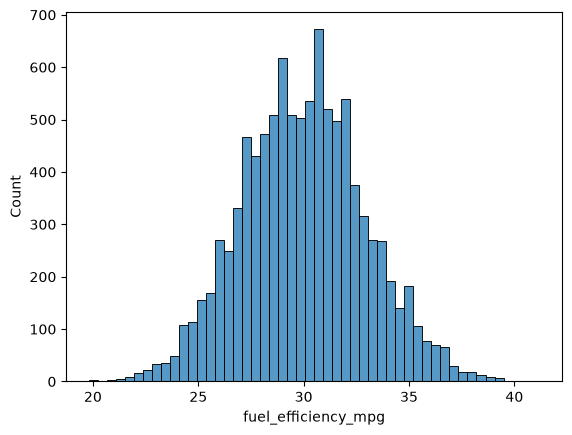

In [11]:
#Check for column long tail (high magnitude discrepancy for values)
sns.histplot(df.fuel_efficiency_mpg, bins=50) #create histogram for distrivbution of car prices against 50 buckets

In [12]:
#Question 1 - Check column with missing values

#Iterate over each column and check number of unique values
for col in df.columns:
    print(col)
    print(df[col].unique()[:5]) #returns unique value in column (first five)
    print(df[col].nunique()) #returns numnber of unique values
    print(df[col].count()) #returns count of non-null values
    print()
#Answer - horsepower has less non-null values

model_year
[2006 2008 1996 1989 1994]
50
10000

engine_displacement
[2180 2390 2320 2130 2580]
127
10000

horsepower
[243. 272. 267. 258. 304.]
153
9123

vehicle_weight
[3870 4210 4240 4490 4510]
176
10000

fuel_efficiency_mpg
[31.9 31.3 27.5 28.5 31. ]
188
10000



In [13]:
#Question 2 - Check median for horsepower column
#import statistics
#horsepower_median = statistics.median(df['horsepower'])
#horsepower_median
df['horsepower'].median() #Ignores not a number

#Answer - 254

np.float64(254.0)

In [14]:
#Code is separating validation, testing and training data (20% for each using random data (instead of sequence))

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train_orig = df_train.fuel_efficiency_mpg.values
y_val_orig = df_val.fuel_efficiency_mpg.values
y_test_orig = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [15]:
df_train

,model_year,engine_displacement,horsepower,vehicle_weight
6252,2015,1900,239.0,3790
4684,1992,2000,224.0,4380
1731,2022,2330,286.0,4090
4742,1997,2300,NaN,4150
4521,2001,2340,269.0,4400
...,...,...,...,...
7895,2018,2280,242.0,4590
9590,1984,2300,NaN,4240
7288,1989,2240,255.0,4190
278,2020,2430,254.0,4280


In [16]:
#Linear regression model
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X) #Multiply X (training data) by the transposed of X
    XTX_inv = np.linalg.inv(XTX) #Inverse Matrix
    w = XTX_inv.dot(X.T).dot(y) #Calculate weights
    
    return w[0], w[1:]

In [17]:
#function to calculate RMSE and compare model result against actual result
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [18]:
#Question 3 - Option 1 (Filled with zero)

#Prepare training data filling with zero the null values
X_train = df_train.fillna(0).values

#Train model
w0, w = train_linear_regression(X_train, y_train_orig)

#Prepare Val data filling with zero the null values
X_val = df_val.fillna(0).values

#Predicted result based on trained model
y_pred = w0 + X_val.dot(w)

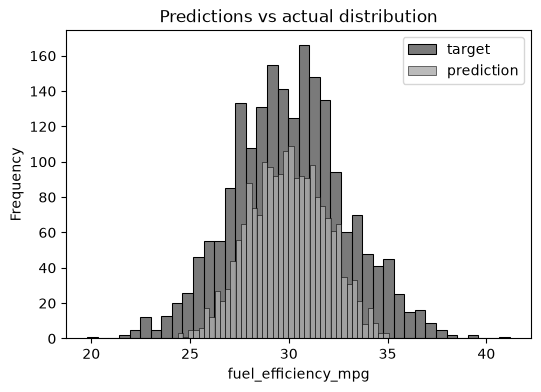

In [19]:
#Prepare Validation data to verify result
plt.figure(figsize=(6, 4))

sns.histplot(y_val_orig, label='target', color='#222222', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='#aaaaaa', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('fuel_efficiency_mpg')
plt.title('Predictions vs actual distribution')
plt.show()

In [20]:
#Calculate RMSE to see model quality and round it
score = rmse(y_val_orig, y_pred)
print(round (score, 3))

2.205


In [21]:
#Question 3 - Option 2 (Filled with mean)

#Prepare training data filling with mean value the horsepower mean value
X_train = df_train.fillna(df_train['horsepower'].mean()).values

#Train model
w0, w = train_linear_regression(X_train, y_train_orig)

#Prepare Val data filling with mean value the horsepower mean value
X_val = df_val.fillna(df_val['horsepower'].mean()).values

#Predicted result based on trained model
y_pred = w0 + X_val.dot(w)

In [22]:
#Calculate RMSE to see model quality and round it
score = rmse(y_val_orig, y_pred)
print(round (score, 3))

2.202


In [23]:
#Linear regression with reularization
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [24]:
#Question 4 - Check models with regularation

X_train = df_train.fillna(0).values
X_val = df_val.fillna(0).values

rList = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in rList:
    #Train model
    w0, w = train_linear_regression_reg(X_train, y_train_orig,r=r)
    y_pred = w0 + X_val.dot(w)
    print ("r:" + str(r))
    print(round(rmse(y_val_orig, y_pred),3))
    print()

r:0
2.205

r:0.01
2.206

r:0.1
2.224

r:1
2.349

r:5
2.409

r:10
2.419

r:100
2.429



In [25]:
#Question 5 - Check different seeds

rmseList = []

seedList = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
for seed in seedList:
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    np.random.seed(int(seed))
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    
    y_train_orig = df_train.fuel_efficiency_mpg.values
    y_val_orig = df_val.fuel_efficiency_mpg.values
    y_test_orig = df_test.fuel_efficiency_mpg.values
    
    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    #Prepare data filling with zero the null values
    X_train = df_train.fillna(0).values
    X_val = df_val.fillna(0).values
    
    #Train model
    w0, w = train_linear_regression(X_train, y_train_orig)
    
    #Predicted result based on trained model
    y_pred = w0 + X_val.dot(w)
    rmseList.append(rmse(y_val_orig, y_pred))

#Calculate Standard deviation
print(round(np.std(rmseList),3))
    

0.029


In [26]:
#Question 6 - Combined dataset


#Prepare Data
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

y_train_orig = df_train.fuel_efficiency_mpg.values
y_val_orig = df_val.fuel_efficiency_mpg.values
y_test_orig = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

#Combine train and val data and reset index
X_full_train = np.concatenate((df_train.fillna(0).values, df_val.fillna(0).values),axis=0)
y_full_train_orig = np.concatenate((y_train_orig, y_val_orig), axis = 0)

#X_full_train = X_full_train.reset_index(drop=True)

#Train model
w0, w = train_linear_regression_reg(X_full_train, y_full_train_orig,r=0.001)

#Prepare test matrix
X_test = df_test.fillna(0)

#Predicted result based on trained model
y_pred = w0 + X_test.dot(w)

print(round(rmse(y_test_orig, y_pred),3))

2.236
